In [2]:
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('train_model.csv')

In [3]:
train['Cluster']

0          1
1          1
2          0
3          0
4          1
          ..
1017204    1
1017205    0
1017206    1
1017207    2
1017208    1
Name: Cluster, Length: 1017209, dtype: int64

In [4]:
train_cluster0 = train[train['Cluster'] == 0]
train_cluster0 = train_cluster0.fillna(0)
train_cluster0["Log_sales"] = np.log(1+train_cluster0["Sales"])

In [5]:
# Apply square root transformation to the "Sales" column
train_cluster0['Sqrt_sales'] = np.sqrt(train_cluster0['Sales'])
train_cluster0=train_cluster0.fillna(0)
train_cluster0["Log_dist"] = np.log(1+train_cluster0["CompetitionDistanceKM"])

In [6]:
train_cluster0['Promo'].unique()

array([0, 1], dtype=int64)

In [6]:
# Assuming your DataFrame is named 'df' and contains columns 'Year', 'Month', and 'Day'
train_cluster0['Date'] = pd.to_datetime(train_cluster0['Date'])
# Set the 'Date' column as the index
train_cluster0.set_index('Date', inplace=True)


In [7]:
train_cluster0.columns

Index(['Unnamed: 0', 'Store', 'DayOfWeek', 'Sales', 'Customers', 'Open',
       'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionDistanceKM', 'DistanceCategory',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
       'CompetitionOpenSinceYear.1', 'WeeksSinceLastCompOpen',
       'MonthsSinceLastCompOpen', 'YearsSinceLastCompOpen', 'Promo2',
       'PromoInterval', 'WeeksSinceLastPromo', 'MonthsSinceLastPromo',
       'YearsSinceLastPromo', 'LastCouponSend', 'DaysSinceCoupon', 'Cluster',
       'Assortment_a', 'Assortment_b', 'Assortment_c', 'StoreType_a',
       'StoreType_b', 'StoreType_c', 'StoreType_d', 'StateHoliday_0',
       'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'Log_sales',
       'Sqrt_sales', 'Log_dist'],
      dtype='object')

In [8]:
train_cluster0 = train_cluster0.drop(columns = ['Unnamed: 0'])

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


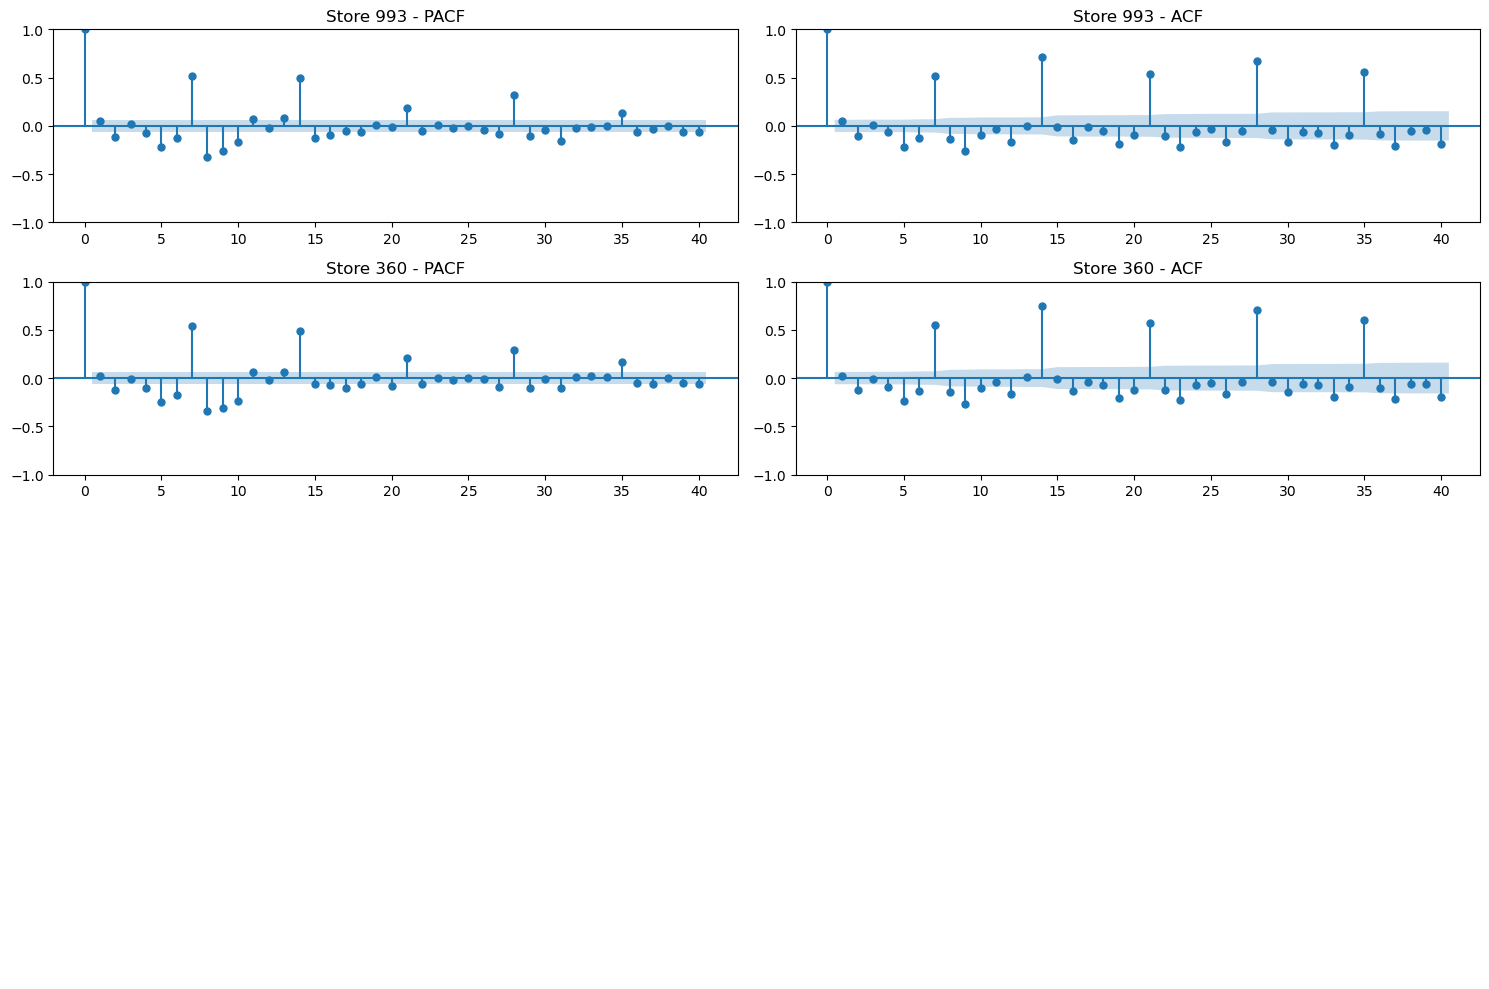

In [9]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster0['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster0[train_cluster0['Store'] == random_stores[0]]['Sales']
sales_store2 = train_cluster0[train_cluster0['Store'] == random_stores[1]]['Sales']

# Step 3: Plot PACF and ACF for each store
fig, axes = plt.subplots(4, 2, figsize=(15, 10))

# PACF for store 1
sm.graphics.tsa.plot_pacf(sales_store1, lags=40, ax=axes[0, 0])
axes[0, 0].set_title(f'Store {random_stores[0]} - PACF')

# ACF for store 1
sm.graphics.tsa.plot_acf(sales_store1, lags=40, ax=axes[0, 1])
axes[0, 1].set_title(f'Store {random_stores[0]} - ACF')

# PACF for store 2
sm.graphics.tsa.plot_pacf(sales_store2, lags=40, ax=axes[1, 0])
axes[1, 0].set_title(f'Store {random_stores[1]} - PACF')

# ACF for store 2
sm.graphics.tsa.plot_acf(sales_store2, lags=40, ax=axes[1, 1])
axes[1, 1].set_title(f'Store {random_stores[1]} - ACF')

# Hide remaining subplots
for ax in axes[2:].flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#Sales are correlated with sales from 1 week ago

C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster0['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster0[train_cluster0['Store'] == random_stores[0]]['Log_sales']
sales_store2 = train_cluster0[train_cluster0['Store'] == random_stores[1]]['Log_sales']

# Step 3: Decompose sales data
decomposition_store1 = seasonal_decompose(sales_store1, model='additive', period=365)  # Assuming yearly seasonality
decomposition_store2 = seasonal_decompose(sales_store2, model='additive', period=365)

# Step 4: Run ADF test for residual component
adf_result_store1 = adfuller(decomposition_store1.resid.dropna())
adf_result_store2 = adfuller(decomposition_store2.resid.dropna())

# Print ADF test results
print(f'ADF test results for Store {random_stores[0]} - p-value: {adf_result_store1[1]}')
print(f'ADF test results for Store {random_stores[1]} - p-value: {adf_result_store2[1]}')

ADF test results for Store 1045 - p-value: 1.374759993895944e-06
ADF test results for Store 16 - p-value: 0.00023191987524747977


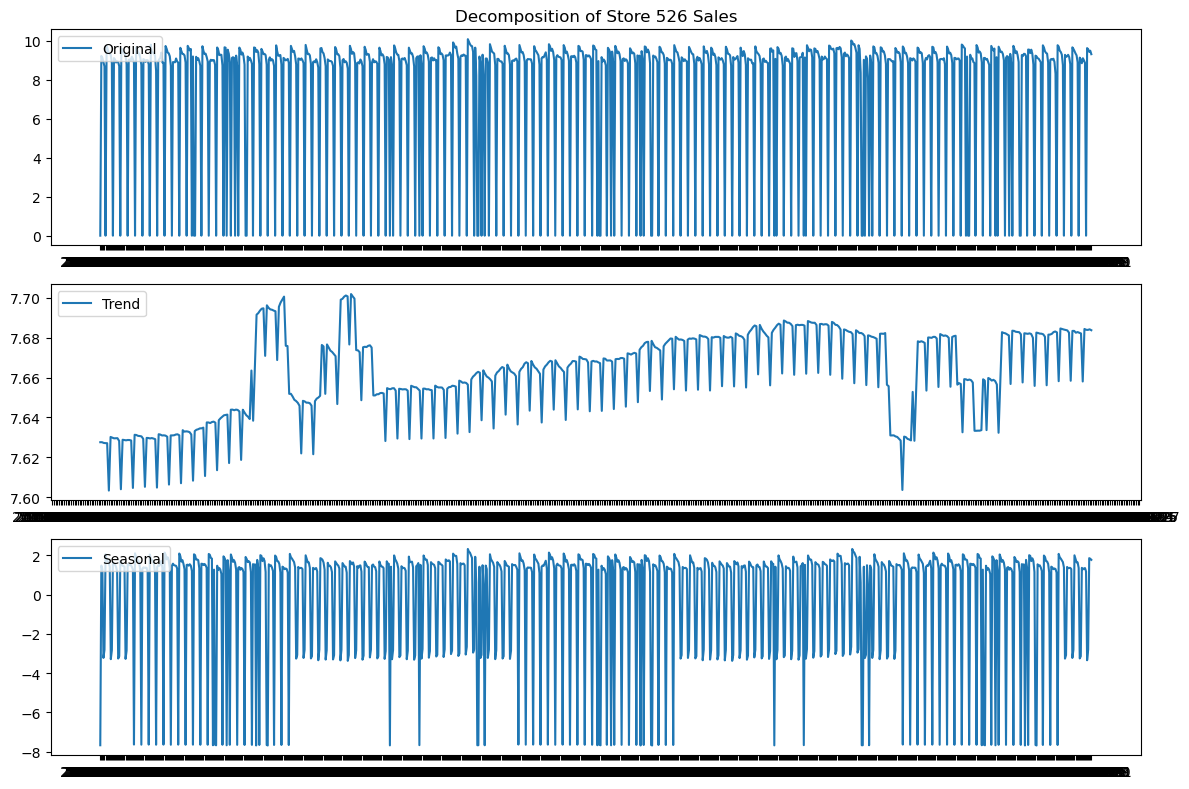

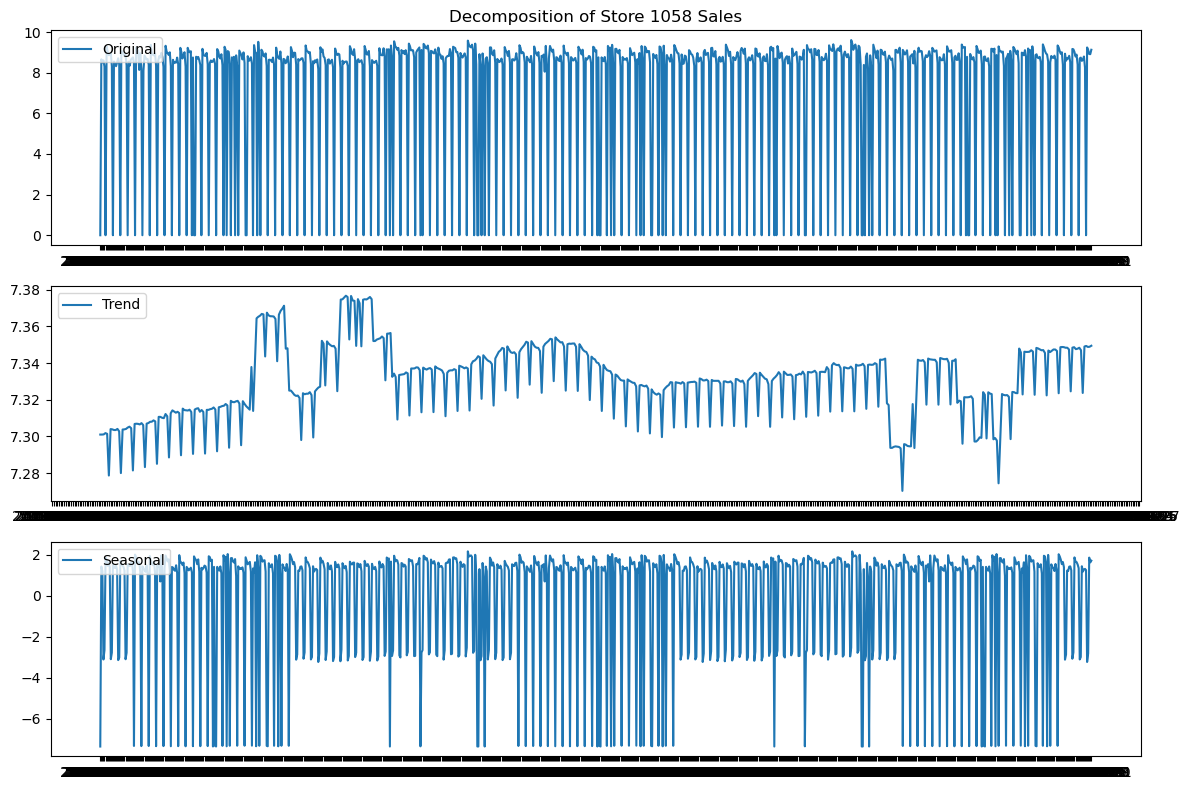

In [148]:
import matplotlib.pyplot as plt

# Plot decomposition for store 1
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store1, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[0]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store1.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store1.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Plot decomposition for store 2
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store2, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[1]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store2.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store2.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
#Stationary

In [11]:
#Add lagged sales
# Define the lagged sales intervals (every 7 days)
lag_intervals = [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]  # Add more intervals as needed

# Iterate over unique store IDs
for store_id in train_cluster0['Store'].unique():
    # Filter data for the current product and store
    condition = (train_cluster0['Store'] == store_id)
    subset = train_cluster0.loc[condition].copy()
        
    # Skip empty subsets
    if subset.empty:
        continue

    # Set lagged features to be the past 14 values
    for lag_interval in lag_intervals:
        subset[f'sales_lag_{lag_interval}'] = subset['Sales'].shift(lag_interval)

    # Drop rows with NaN values resulting from lagged shifting
    subset = subset.dropna()

    # Update the original DataFrame with the lagged features
    train_cluster0.loc[condition, subset.columns] = subset

# Drop NaN value resulting from the lagged variable
train_cluster0 = train_cluster0.dropna()
train_cluster0


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionDistanceKM,DistanceCategory,...,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,,,,,,
2013-03-12,3.0,2.0,5452.0,704.0,1.0,0.0,0.0,14130.0,14.13,Far,...,9878.0,5154.0,7997.0,5725.0,9372.0,5375.0,7961.0,5041.0,9800.0,0.0
2013-03-12,4.0,2.0,7676.0,1150.0,1.0,0.0,0.0,620.0,0.62,Close,...,9844.0,7199.0,9719.0,7800.0,11353.0,7559.0,9977.0,7121.0,10031.0,0.0
2013-03-12,7.0,2.0,7182.0,920.0,1.0,0.0,0.0,24000.0,24.00,Far,...,9821.0,6464.0,8497.0,6506.0,9502.0,6480.0,9074.0,6780.0,10073.0,0.0
2013-03-12,11.0,2.0,7702.0,1177.0,1.0,0.0,0.0,960.0,0.96,Close,...,9864.0,6418.0,8218.0,6563.0,8478.0,5957.0,8042.0,6461.0,9422.0,0.0
2013-03-12,12.0,2.0,5872.0,763.0,1.0,0.0,0.0,1070.0,1.07,Close,...,9035.0,4959.0,8564.0,5226.0,7563.0,5424.0,8342.0,4579.0,9114.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,1093.0,5.0,11778.0,1071.0,1.0,1.0,1.0,10450.0,10.45,Far,...,7659.0,8049.0,9236.0,9230.0,7320.0,9265.0,7819.0,9142.0,11057.0,8864.0
2015-07-31,1097.0,5.0,11443.0,2451.0,1.0,1.0,1.0,720.0,0.72,Close,...,9948.0,10876.0,10480.0,12688.0,9710.0,10712.0,10392.0,11999.0,11026.0,10349.0
2015-07-31,1099.0,5.0,12074.0,1370.0,1.0,1.0,1.0,200.0,0.20,Close,...,11643.0,8239.0,10103.0,9259.0,6671.0,8130.0,6373.0,8484.0,9298.0,7774.0


In [12]:
cont_features = train_cluster0.iloc[:,[22,37,38,39,40,41,42,43,44,45,46,47]]
cont_features

,DaysSinceCoupon,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,
2013-03-12,70.0,2.716680,9878.0,5154.0,7997.0,5725.0,9372.0,5375.0,7961.0,5041.0,9800.0,0.0
2013-03-12,0.0,0.482426,9844.0,7199.0,9719.0,7800.0,11353.0,7559.0,9977.0,7121.0,10031.0,0.0
2013-03-12,0.0,3.218876,9821.0,6464.0,8497.0,6506.0,9502.0,6480.0,9074.0,6780.0,10073.0,0.0
2013-03-12,70.0,0.672944,9864.0,6418.0,8218.0,6563.0,8478.0,5957.0,8042.0,6461.0,9422.0,0.0
2013-03-12,70.0,0.727549,9035.0,4959.0,8564.0,5226.0,7563.0,5424.0,8342.0,4579.0,9114.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,0.0,2.437990,7659.0,8049.0,9236.0,9230.0,7320.0,9265.0,7819.0,9142.0,11057.0,8864.0
2015-07-31,0.0,0.542324,9948.0,10876.0,10480.0,12688.0,9710.0,10712.0,10392.0,11999.0,11026.0,10349.0
2015-07-31,30.0,0.182322,11643.0,8239.0,10103.0,9259.0,6671.0,8130.0,6373.0,8484.0,9298.0,7774.0


In [13]:
train_cluster0.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'CompetitionDistanceKM',
       'DistanceCategory', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'CompetitionOpenSinceYear.1',
       'WeeksSinceLastCompOpen', 'MonthsSinceLastCompOpen',
       'YearsSinceLastCompOpen', 'Promo2', 'PromoInterval',
       'WeeksSinceLastPromo', 'MonthsSinceLastPromo', 'YearsSinceLastPromo',
       'LastCouponSend', 'DaysSinceCoupon', 'Cluster', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'Log_sales', 'Sqrt_sales',
       'Log_dist', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_35', 'sales_lag_42', 'sales_lag_49',
       'sales_lag_56', 'sales_lag_63', 'sales_lag_70'],
      dtype='object')

In [14]:
cat_features = train_cluster0.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34]]
cat_features

,DayOfWeek,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
Date,,,,,,,,,,,,,,,,
2013-03-12,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,5.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [15]:
features = train_cluster0.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34,22,37,38,39,40,41,42,43,44,45,46,47]]

0

In [16]:
#Find relationship between sales and special offer
import statsmodels.api as sm
# Add a constant term to the independent variables
X = sm.add_constant(features)

# Define dependent variable
y = train_cluster0['Sqrt_sales']

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())
#p-value is low, which means there is significant relationship between sales and special offer

                            OLS Regression Results                            
Dep. Variable:             Sqrt_sales   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                 3.031e+05
Date:                Thu, 09 May 2024   Prob (F-statistic):               0.00
Time:                        16:54:55   Log-Likelihood:            -1.2663e+06
No. Observations:              366056   AIC:                         2.533e+06
Df Residuals:                  366030   BIC:                         2.533e+06
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -17.5359      0.078   -2

In [51]:
train_cluster0.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'CompetitionDistanceKM',
       'DistanceCategory', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'CompetitionOpenSinceYear.1',
       'WeeksSinceLastCompOpen', 'MonthsSinceLastCompOpen',
       'YearsSinceLastCompOpen', 'Promo2', 'PromoInterval',
       'WeeksSinceLastPromo', 'MonthsSinceLastPromo', 'YearsSinceLastPromo',
       'LastCouponSend', 'DaysSinceCoupon', 'Cluster', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'Log_sales', 'Sqrt_sales',
       'Log_dist', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_35', 'sales_lag_42', 'sales_lag_49',
       'sales_lag_56', 'sales_lag_63', 'sales_lag_70'],
      dtype='object')

In [55]:
corrmatrix = train_cluster0.iloc[:,[3,13,18,22,36,37,38,39,40,41,42,43,44,45,46,47]]
corrmatrix

,Customers,WeeksSinceLastCompOpen,WeeksSinceLastPromo,DaysSinceCoupon,Sqrt_sales,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,
2013-03-12,704.0,328,102,70.0,73.837660,2.716680,9878.0,5154.0,7997.0,5725.0,9372.0,5375.0,7961.0,5041.0,9800.0,0.0
2013-03-12,1150.0,184,,0.0,87.612784,0.482426,9844.0,7199.0,9719.0,7800.0,11353.0,7559.0,9977.0,7121.0,10031.0,0.0
2013-03-12,920.0,,,0.0,84.746681,3.218876,9821.0,6464.0,8497.0,6506.0,9502.0,6480.0,9074.0,6780.0,10073.0,0.0
2013-03-12,1177.0,71,63,70.0,87.761039,0.672944,9864.0,6418.0,8218.0,6563.0,8478.0,5957.0,8042.0,6461.0,9422.0,0.0
2013-03-12,763.0,,155,70.0,76.628976,0.727549,9035.0,4959.0,8564.0,5226.0,7563.0,5424.0,8342.0,4579.0,9114.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,1071.0,322,,0.0,108.526494,2.437990,7659.0,8049.0,9236.0,9230.0,7320.0,9265.0,7819.0,9142.0,11057.0,8864.0
2015-07-31,2451.0,700,,0.0,106.971959,0.542324,9948.0,10876.0,10480.0,12688.0,9710.0,10712.0,10392.0,11999.0,11026.0,10349.0
2015-07-31,1370.0,122,122,30.0,109.881755,0.182322,11643.0,8239.0,10103.0,9259.0,6671.0,8130.0,6373.0,8484.0,9298.0,7774.0


C:\Users\PC\AppData\Local\Temp\ipykernel_44964\1221675179.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = corrmatrix.corr(method='pearson')


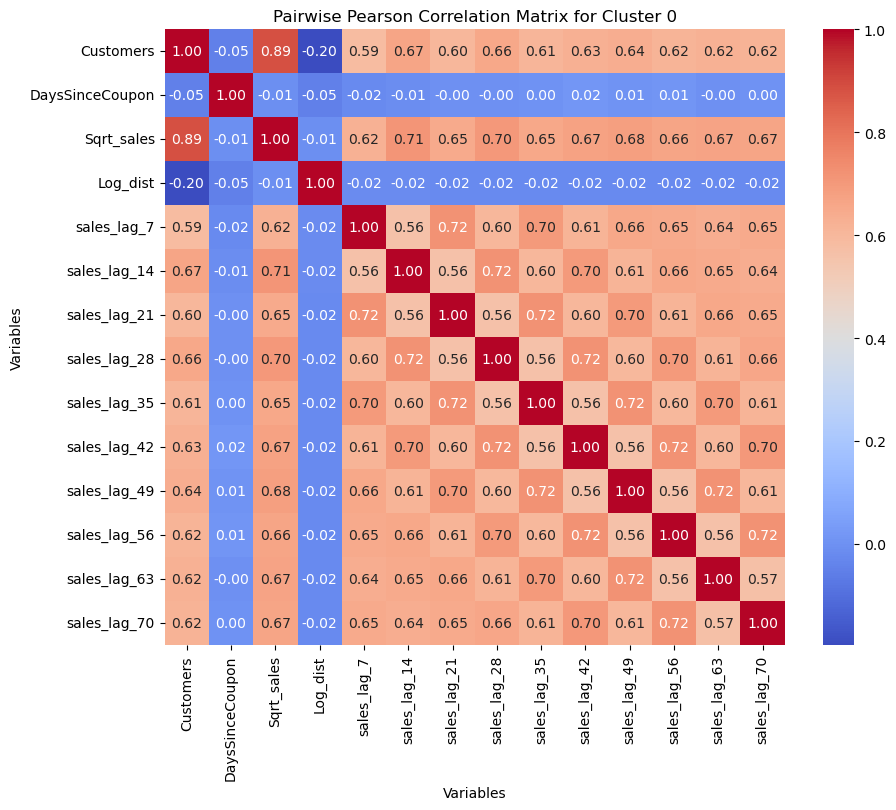

In [57]:
import pandas as pd
import seaborn as sns

# Assuming your DataFrame is named 'df' and contains the variables for which you want to compute correlations

# Compute pairwise Pearson correlation matrix
correlation_matrix = corrmatrix.corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pairwise Pearson Correlation Matrix for Cluster 0")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

Point Biserial test

In [58]:
from scipy.stats import pointbiserialr

# Assuming your DataFrame is named 'df' and contains the binary feature columns and the 'Sales' column

# Iterate over each binary feature column
for column in cat_features.columns:
    # Calculate Point-Biserial correlation coefficient and p-value
    correlation_coefficient, p_value = pointbiserialr(train_cluster0[column], train_cluster0['Sales'])
    
    # Print results
    print(f"Point-Biserial Correlation for Cluster 0 {column}: {correlation_coefficient}, p-value: {p_value}")
#Remove Open and Promo

Point-Biserial Correlation for Cluster 0 DayOfWeek: -0.5603890792141182, p-value: 0.0
Point-Biserial Correlation for Cluster 0 Open: 0.8016476694451489, p-value: 0.0
Point-Biserial Correlation for Cluster 0 Promo: 0.5462402142352695, p-value: 0.0
Point-Biserial Correlation for Cluster 0 SchoolHoliday: 0.10361734693211518, p-value: 0.0
Point-Biserial Correlation for Cluster 0 Promo2: -0.019855957398524644, p-value: 2.9814513439575183e-33
Point-Biserial Correlation for Cluster 0 Assortment_a: -0.017811831979202098, p-value: 4.399943817925312e-27
Point-Biserial Correlation for Cluster 0 Assortment_b: 0.03855438502207529, p-value: 1.957846288156673e-120
Point-Biserial Correlation for Cluster 0 Assortment_c: 0.014033532931748936, p-value: 2.048030426360442e-17
Point-Biserial Correlation for Cluster 0 StoreType_a: 0.020747945612634013, p-value: 3.7627239726485415e-36
Point-Biserial Correlation for Cluster 0 StoreType_b: 0.03518800839831357, p-value: 1.231954860081015e-100
Point-Biserial Corr

In [17]:
features.columns
features = features.drop(columns = ['StoreType_c'])

# Cross-validation for ML models

0. Baseline model

In [19]:
#MSE of baseline model to compare with
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Assign 'y_true' as the actual target variable and 'y_pred_mean' as the mean prediction
y_true = train_cluster0['Sqrt_sales'] 
y_pred_mean = np.full_like(y_true, y_true.mean())  # Predicting the mean for every sample

mae_base = mean_absolute_error(y_true, y_pred_mean)
print(f'MAE: {mae_base}')
# Calculate MSE for the mean prediction
mse_base = mean_squared_error(y_true, y_pred_mean)
print(f'Mean Squared Error for Mean Prediction: {mse_base}')

MAE: 26.348656402504744
Mean Squared Error for Mean Prediction: 1284.7762857783323


1. Lagged sales

In [23]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

#Linear Regression with lagged features with raw data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = features
y = train_cluster0['Sales']
        
# Perform cross-validation predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)
percentage_error = (y_pred_cv - y) / (y + 1e-6) * 100
# Calculate Root Mean Square Percentage Error (RMSPE)
rmspe = np.sqrt(np.mean(np.square(percentage_error)))
print("Root Mean Square Percentage Error (RMSPE):", rmspe)
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

Root Mean Square Percentage Error (RMSPE): 37257562619.336426
MSE Scores for Linear Regression with raw data: 2421049.766907228
R2 Scores for Linear Regression with raw data: 0.8373690003889374


In [24]:
#Linear Regression on logged sales
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = features
y = train_cluster0['Sqrt_sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of mean squared error scores
mae_linear_scaled = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression: {mae_linear_scaled}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

MAE Scores for Linear Regression: 5.535394745299675
MSE Scores for Linear Regression with raw data: 65.33280866690885
R2 Scores for Linear Regression with raw data: 0.9491254044566448


In [25]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

#Random Forest with raw data 

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

X = features
y = train_cluster0['Sqrt_sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mean_mae_RF = -np.mean(mae_scores)
# Display the mean of MSE scores
print(f'MAE Scores for RF with raw data: {mean_mae_RF}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_RF = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with raw data: {mean_mse_RF}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_RF = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'Mean of R2 Scores for RF: {mean_r2_RF}')

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptro

MAE Scores for RF with raw data: 20.577525937647813


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE Scores for RF with raw data: 997.7337702211742


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean of R2 Scores for RF: 0.869064437272294


1.1. Lagged features with scaling 

2. Log_sales

In [ ]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Linear Regression with lagged features with raw data

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = features
y = train_cluster0['Sales']
        
# Perform time series cross-validation and get MSE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mae_linear = -np.mean(mae_scores)
# Display the mean of mean squared error scores
print(f'MAE Scores for Linear Regression with raw data: {mean_mae_linear}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

# Using Linear model for prediction

3.2. Predict using linear model

In [59]:
#Use the Linear Regression model on raw data with 14 lagged sales and offer
#Set Train data
X_train = features
y_train = train_cluster0['Sqrt_sales']
        
# Initialize a model
final_model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

# Train the model on the historical data from 2016
final_model.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(10, 5), max_iter=100)

In [27]:
test = pd.read_csv('test_model.csv', parse_dates = ['Date'], dayfirst=True, low_memory = False)
test = test.drop(columns = "Unnamed: 0")
test.set_index('Date', inplace=True)

In [28]:
test_cluster = test[test['Cluster'] == 0]

In [29]:
test_cluster.columns
test_cluster = test_cluster.drop(columns = ['Sales','Customers','Competitionsincedate','WeeksSinceLastCompOpen','Promosincedate',
       'WeeksSinceLastPromo','Cluster','LastCouponSend'])
test_cluster['StateHoliday_b'] = 0
test_cluster['StateHoliday_c'] = 0
test_cluster['Log_dist'] = np.log(test_cluster['CompetitionDistance'])

In [30]:
features.columns

Index(['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'Promo2', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'DaysSinceCoupon', 'Log_dist', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_lag_35',
       'sales_lag_42', 'sales_lag_49', 'sales_lag_56', 'sales_lag_63',
       'sales_lag_70'],
      dtype='object')

In [31]:
test_features = test_cluster.drop(columns = 'CompetitionDistance')

In [33]:
train_cluster0['Store'] = train_cluster0['Store'].astype(int)

In [34]:
cluster_tomerge = train_cluster0.iloc[:,[0,1,2]]
# Filter train_df to include data from 70 days before 31/7/2015
start_date_train = pd.to_datetime('2015-05-22')  # 70 days before 31/7/2015
train_df_filtered = cluster_tomerge[cluster_tomerge.index >= start_date_train]

# Concatenate train and test datasets vertically
combined_df = pd.concat([train_df_filtered, test_features], axis=0)


In [35]:
combined_df['Date']=combined_df.index

In [36]:
combined_df = combined_df[['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'SchoolHoliday',
       'Promo2', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c','DaysSinceCoupon','Log_dist', 'Date']]

In [37]:
combined_df['DaysSinceCoupon']=combined_df['DaysSinceCoupon'].fillna(0).astype(int)

In [38]:
import random
# Extract unique store numbers from the "Store" column
unique_store_numbers = test_features['Store'].unique()

# Choose 2 random store numbers
random_store_numbers = random.sample(list(unique_store_numbers), 2)

# Now 'random_store_numbers' contains 2 randomly chosen store numbers from the "Store" column
print("Randomly chosen store numbers:", random_store_numbers)

Randomly chosen store numbers: [388, 180]


In [39]:
test_0 = test_features.copy()

# List to store subsets with lagged features
lagged_subsets = []

for store in random_store_numbers:
    # Filter data for the current product and store
    condition = (combined_df['Store'] == store)
    subset = combined_df.loc[condition].copy()
        
    lagged_subsets.append(subset)

In [40]:
lagged_subsets

[            Store  DayOfWeek    Sales  Open  Promo  SchoolHoliday  Promo2  \
 Date                                                                        
 2015-05-22    388        5.0  10710.0   NaN    NaN            NaN     NaN   
 2015-05-23    388        6.0   8501.0   NaN    NaN            NaN     NaN   
 2015-05-24    388        7.0      0.0   NaN    NaN            NaN     NaN   
 2015-05-25    388        1.0      0.0   NaN    NaN            NaN     NaN   
 2015-05-26    388        2.0  10244.0   NaN    NaN            NaN     NaN   
 ...           ...        ...      ...   ...    ...            ...     ...   
 2015-09-13    388        7.0      NaN   0.0    0.0            0.0     0.0   
 2015-09-14    388        1.0      NaN   1.0    1.0            0.0     0.0   
 2015-09-15    388        2.0      NaN   1.0    1.0            0.0     0.0   
 2015-09-16    388        3.0      NaN   1.0    1.0            0.0     0.0   
 2015-09-17    388        4.0      NaN   1.0    1.0            0

In [60]:
# Specify the date range for training and testing
start_date_test = pd.to_datetime('2015-08-01')
end_date_test = pd.to_datetime('2015-09-17')

predicted_sales = []

for subset in (lagged_subsets):
    # Initialize test_data once for the entire subset
    subset_test = subset.copy()

    for day in pd.date_range(start=start_date_test, end=end_date_test):
        test_data = subset_test[subset_test['Date'] <= day].copy()
        # Create lagged sales features for each week up to 10 weeks ago
        num_weeks = 10
        for i in range(1, num_weeks + 1):
            lagged_sales_col = f'sales_lag_{i * 7}'  # Create column name for lagged sales
            test_data[lagged_sales_col] = test_data['Sales'].shift(i * 7)  # Shift sales by multiples of 7 days

        # Drop rows with NaN values resulting from lagged shifting
        test_data = test_data.fillna(0)

        #Make X_test
        x = test_data.drop(['Sales','Store','StoreType_c'],axis=1)
        X_test = x[x['Date'] == day].drop('Date',axis = 1)
        
        #Initiate the predictions
        predictions = final_model.predict(X_test)

        #Update the subset
        subset_test.loc[subset['Date'] == day, 'Sales'] = predictions**2
    
    #Retain the only part from 31/07/2017 onward
    subset_test = subset_test[subset_test['Date'] >= start_date_test]
    # Replace the old subset with the updated one in lagged_subsets
    predicted_sales.append(subset_test)

In [61]:
store388 = predicted_sales[0]
store388.loc[store388['Sales'] < 10, 'Sales'] = 0
store388

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,388,6.0,7205.374638,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-01
2015-08-02,388,7.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-02
2015-08-03,388,1.0,14994.413095,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-03
2015-08-04,388,2.0,11328.161402,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-04
2015-08-05,388,3.0,10759.691354,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-05
2015-08-06,388,4.0,10111.578679,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-06
2015-08-07,388,5.0,11258.733227,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-07
2015-08-08,388,6.0,6960.800417,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-08
2015-08-09,388,7.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,7.72312,2015-08-09


In [62]:
store180 = predicted_sales[1]
store180.loc[store388['Sales'] < 10, 'Sales'] = 0
store180

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,180,6.0,6348.785510,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-01
2015-08-02,180,7.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-02
2015-08-03,180,1.0,10447.409269,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-03
2015-08-04,180,2.0,8189.832773,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-04
2015-08-05,180,3.0,8223.245127,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-05
2015-08-06,180,4.0,8561.871854,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-06
2015-08-07,180,5.0,8831.408404,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-07
2015-08-08,180,6.0,6245.111956,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-08
2015-08-09,180,7.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,8.665613,2015-08-09


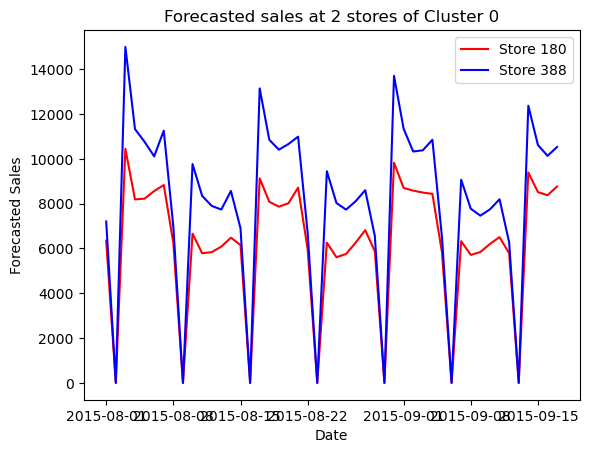

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_actual is your DataFrame containing the actual sales data
# Assuming df_forecast is your DataFrame containing the forecasted sales for the next 15 days

# Plot forecasted sales data
plt.plot(store180['Sales'], label='Store 180', color='red')
plt.plot(store388['Sales'], label='Store 388', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.title('Forecasted sales at 2 stores of Cluster 0')
plt.legend()
# Show plot
plt.show()

In [120]:
store410 = predicted_sales[0]
# Replace negative sales values with 0
store410.loc[store410['Sales'] < 1, 'Sales'] = 0
